## Exercise - Create and Visualize Calendar Features
Create the following calendar features:

- `hour`
- `dayofweek`
- `is_weekend`
- `month`
- `season`

Then create three plots:

1. Average consumption by hour of day
2. Average consumption for weekdays vs weekends
3. Average consumption by season

### Questions

Answer the following questions based on the plots:

1. During which hours is average consumption highest? Lowest?
2. Is there a visible difference between weekdays and weekends?
3. Why might season be useful in Estonian electricity consumption data? Explain with the help of the plot.
4. Which created feature would likely be most useful for forecasting, and why?

### Hint
```python
elering.loc[elering["month"].isin([6, 7, 8]), "season"] = "summer"

### Answers

1. Average consumption is the highest during the hours of 9:00-13:00 and 17:00-18:00, and the lowest during nightime, hitting a minimum at 04:00.
2. Yes - average consumption is noticeably **higher on weekdays**.
3. Season could be especially useful in Estonian electricity consumption data because it is strongly affected by seasonal conditions. In winter, colder temperatures, shorter daylight hours, and larger heating and lighting needs can increase electricity demand. In the plot, winter has the highest average consumption, while summer has the lowest, which is expected as summer has warmer weather and much longer daylight hours. 
4.  All would be useful, but the `hour` feature would likely be the most helpful, as the hourly plot follows a distinct daily pattern.

In [11]:
# Imports

import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import missingno as msno

In [ ]:
# Read the data and set timestamp as the index

elering = pd.read_csv('../data/electricity-production and consumption_2022.csv',  delimiter=';',decimal=',')
elering['timestamp'] = pd.to_datetime(elering['Kuupaev (Eesti aeg)'], dayfirst=True)
elering.set_index('timestamp', inplace=True)

In [ ]:
elering["hour"] = elering.index.hour
elering["dayofweek"] = elering.index.dayofweek
elering["is_weekend"] = elering["dayofweek"].isin([5, 6])
elering["month"] = elering.index.month

elering.loc[elering["dayofweek"].isin([5, 6]), "is_weekend"] = True
elering.loc[elering["dayofweek"].isin([0, 1, 2, 3, 4]), "is_weekend"] = False


elering.loc[elering["month"].isin([3, 4, 5]), "season"] = "spring"
elering.loc[elering["month"].isin([6, 7, 8]), "season"] = "summer"
elering.loc[elering["month"].isin([9, 10, 11]), "season"] = "autumn"
elering.loc[elering["month"].isin([12, 1, 2]), "season"] = "winter"

#elering[["hour", "dayofweek", "is_weekend", "month"]].head()


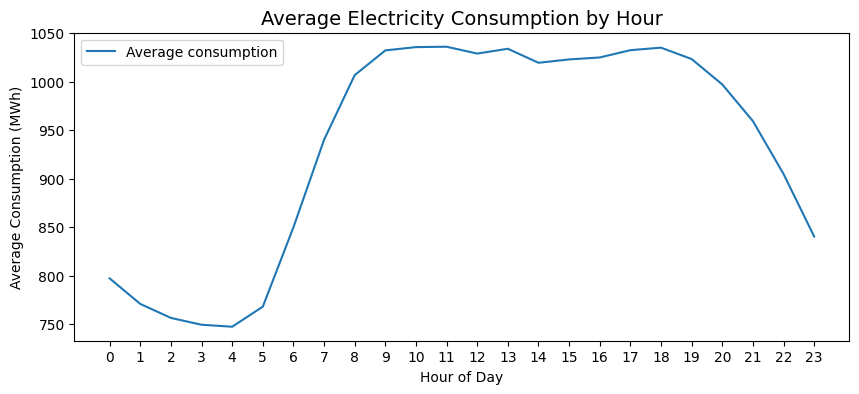

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(elering.groupby("hour")["Tarbimine"].mean(), label="Average consumption")
plt.title("Average Electricity Consumption by Hour", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(range(0, 24))
plt.legend()
plt.show()

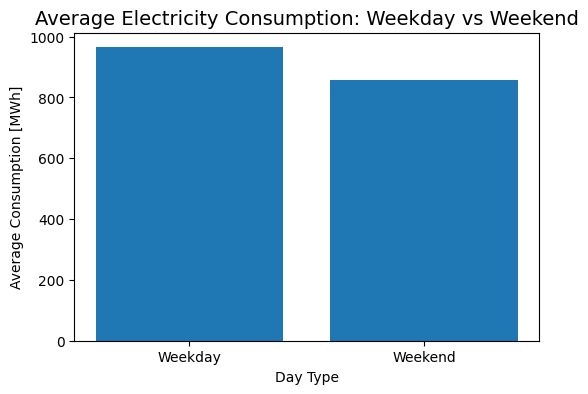

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(["Weekday", "Weekend"], elering.groupby("is_weekend")["Tarbimine"].mean())
plt.title("Average Electricity Consumption: Weekday vs Weekend", fontsize=14)
plt.xlabel("Day Type")
plt.ylabel("Average Consumption (MWh)")
plt.show()

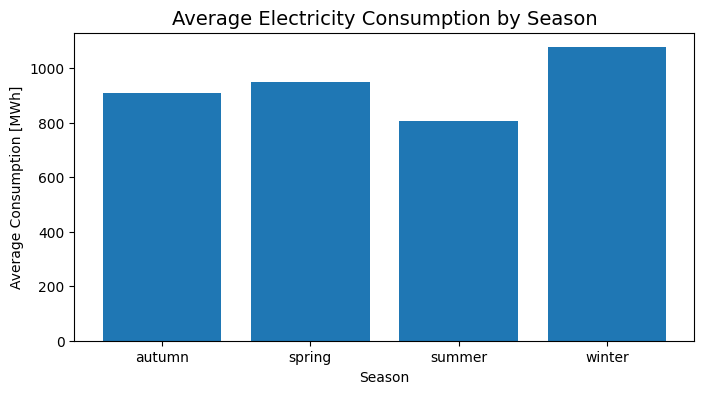

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(elering.groupby("season")["Tarbimine"].mean().index,
        elering.groupby("season")["Tarbimine"].mean())
plt.title("Average Electricity Consumption by Season", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Average Consumption (MWh)")
plt.show()